# Classifying Air Showers: Logistic Regression vs. Support Vector Machines
**MAGIC Gamma Telescope dataset — corrected analysis notebook**

This notebook implements the cross-validation, model-comparison, and model-estimation
workflow for distinguishing gamma-ray events from hadron (background) events.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.pipeline import make_pipeline         
from sklearn.preprocessing import StandardScaler    
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC                     


from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, roc_curve, auc)

RANDOM_STATE = 0   
plt.rcParams["figure.dpi"] = 120

In [3]:
COLS = ["fLength", "fWidth", "fSize", "fConc", "fConc1",
        "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]

try:
    
    from ucimlrepo import fetch_ucirepo
    magic = fetch_ucirepo(id=159)
    df = magic.data.features.copy()
    df["class"] = magic.data.targets.iloc[:, 0].values
except Exception as e:
    print("ucimlrepo not available, falling back to direct URL:", e)
    URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "magic/magic04.data")
    df = pd.read_csv(URL, header=None, names=COLS)


df["class"] = df["class"].map({"g": 1, "h": 0}).astype(int)

FEATURES = COLS[:-1]
X = df[FEATURES]      
y = df["class"]       

print(f"n = {len(df)} observations, p = {len(FEATURES)} predictors")
print("Class balance (1=gamma, 0=hadron):")
print(y.value_counts(normalize=True).round(3))
df.head()

ucimlrepo not available, falling back to direct URL: No module named 'ucimlrepo'
n = 19020 observations, p = 10 predictors
Class balance (1=gamma, 0=hadron):
class
1    0.648
0    0.352
Name: proportion, dtype: float64


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


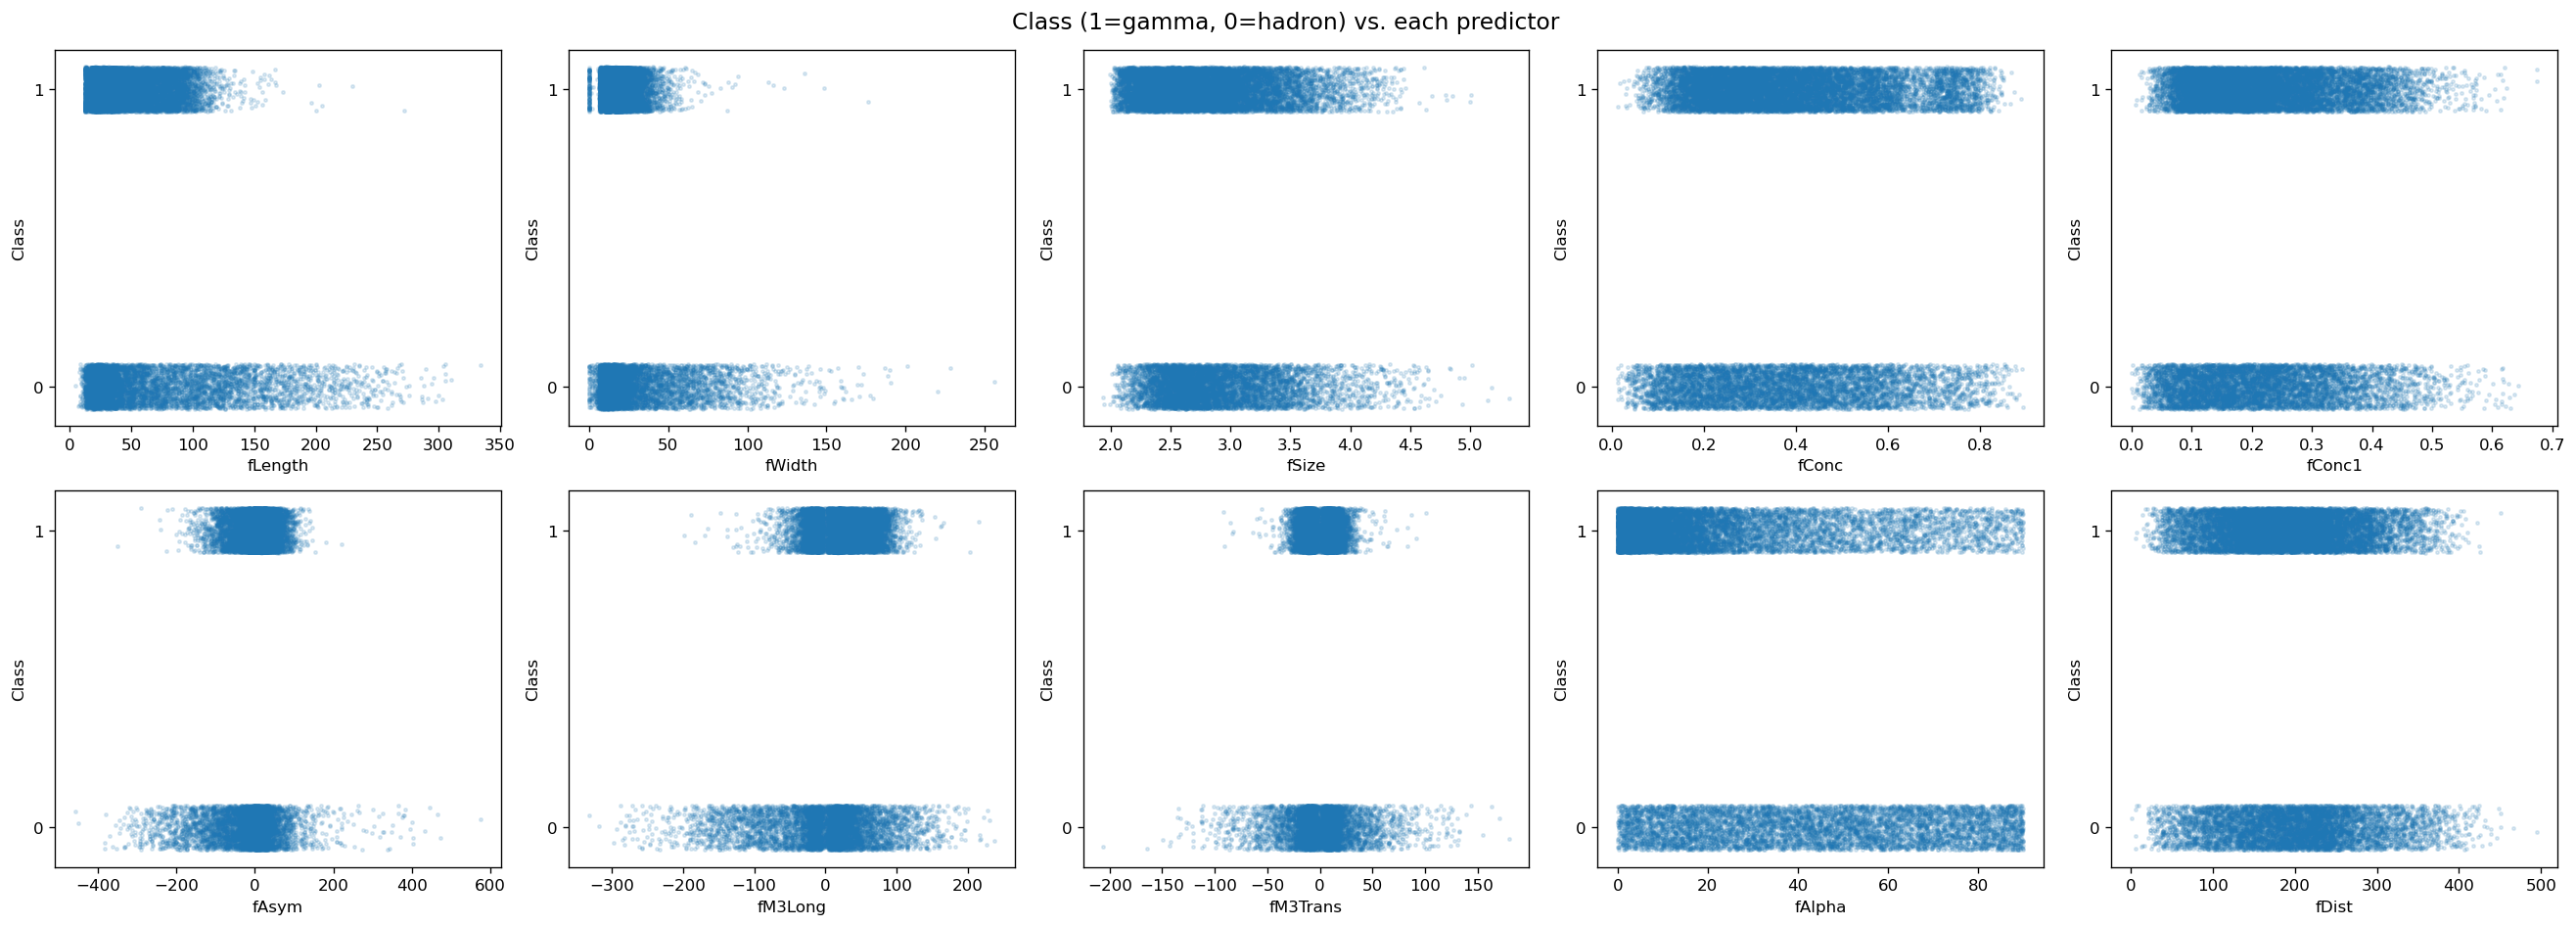

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 8))
for ax, feat in zip(axes.flat, FEATURES):
    
    jitter = (np.random.rand(len(y)) - 0.5) * 0.15
    ax.scatter(df[feat], y + jitter, s=4, alpha=0.15)
    ax.set_xlabel(feat)
    ax.set_ylabel("Class")
    ax.set_yticks([0, 1])
fig.suptitle("Class (1=gamma, 0=hadron) vs. each predictor", fontsize=14)
fig.tight_layout()
plt.show()

In [4]:
lmbda = 10 ** np.linspace(-1, 1, num=10)   
Cs = 1.0 / lmbda                            

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_lr(C):
    
                         LogisticRegression(C=C, max_iter=1000))

def make_svm(C):
   
    return make_pipeline(StandardScaler(),
                         LinearSVC(C=C, max_iter=10000, dual=True, random_state=RANDOM_STATE))

print("lambda grid:", np.round(lmbda, 3))

lambda grid: [ 0.1    0.167  0.278  0.464  0.774  1.292  2.154  3.594  5.995 10.   ]


In [5]:
from sklearn.model_selection import cross_validate

log_cv  = np.zeros(len(Cs)); log_train = np.zeros(len(Cs))
svm_cv  = np.zeros(len(Cs)); svm_train = np.zeros(len(Cs))

for i, C in enumerate(Cs):
    
    lr_res = cross_validate(make_lr(C),  X, y, cv=cv, scoring="accuracy", return_train_score=True)
    sv_res = cross_validate(make_svm(C), X, y, cv=cv, scoring="accuracy", return_train_score=True)
    log_cv[i], log_train[i] = lr_res["test_score"].mean(), lr_res["train_score"].mean()
    svm_cv[i], svm_train[i] = sv_res["test_score"].mean(), sv_res["train_score"].mean()
    print(f"lambda={lmbda[i]:6.3f} | LR cv={log_cv[i]:.4f}  SVM cv={svm_cv[i]:.4f}")

C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


lambda= 0.100 | LR cv=0.7904  SVM cv=0.7889


C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


lambda= 0.167 | LR cv=0.7905  SVM cv=0.7889


C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Shawn\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


lambda= 0.278 | LR cv=0.7905  SVM cv=0.7889
lambda= 0.464 | LR cv=0.7904  SVM cv=0.7889
lambda= 0.774 | LR cv=0.7903  SVM cv=0.7889
lambda= 1.292 | LR cv=0.7903  SVM cv=0.7889
lambda= 2.154 | LR cv=0.7903  SVM cv=0.7889
lambda= 3.594 | LR cv=0.7904  SVM cv=0.7889
lambda= 5.995 | LR cv=0.7905  SVM cv=0.7889
lambda=10.000 | LR cv=0.7904  SVM cv=0.7888


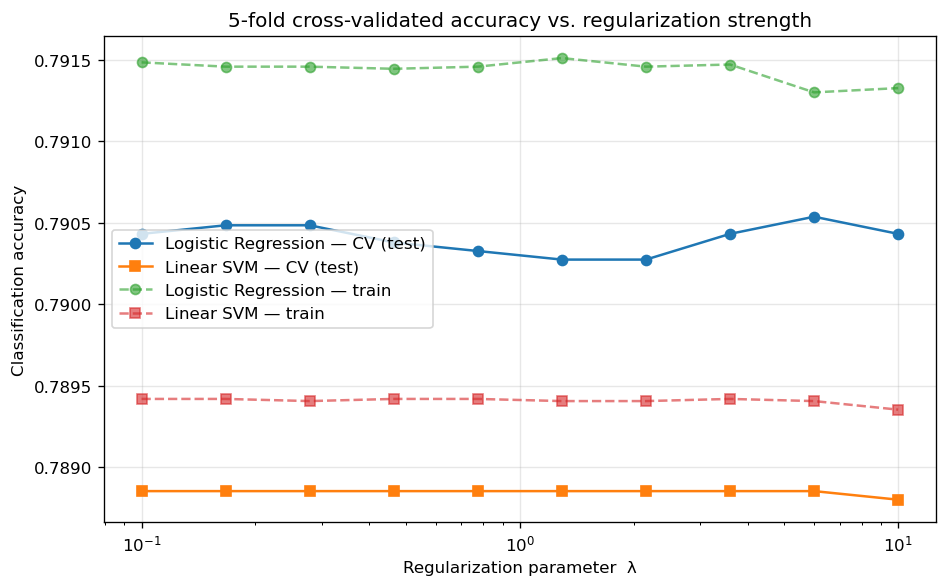

In [6]:
plt.figure(figsize=(8, 5))
plt.semilogx(lmbda, log_cv,    "o-", label="Logistic Regression — CV (test)")
plt.semilogx(lmbda, svm_cv,    "s-", label="Linear SVM — CV (test)")
plt.semilogx(lmbda, log_train, "o--", alpha=.6, label="Logistic Regression — train")
plt.semilogx(lmbda, svm_train, "s--", alpha=.6, label="Linear SVM — train")
plt.xlabel("Regularization parameter  λ")
plt.ylabel("Classification accuracy")
plt.title("5-fold cross-validated accuracy vs. regularization strength")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [7]:
best_lr_idx,  best_svm_idx  = log_cv.argmax(), svm_cv.argmax()
best_lr_lambda, best_svm_lambda = lmbda[best_lr_idx], lmbda[best_svm_idx]

summary = pd.DataFrame({
    "Method": ["Logistic Regression", "Linear SVM"],
    "Best lambda": [round(best_lr_lambda, 3), round(best_svm_lambda, 3)],
    "CV accuracy": [round(log_cv[best_lr_idx], 4), round(svm_cv[best_svm_idx], 4)],
})
summary

,Method,Best lambda,CV accuracy
0,Logistic Regression,5.995,0.7905
1,Linear SVM,0.100,0.7889


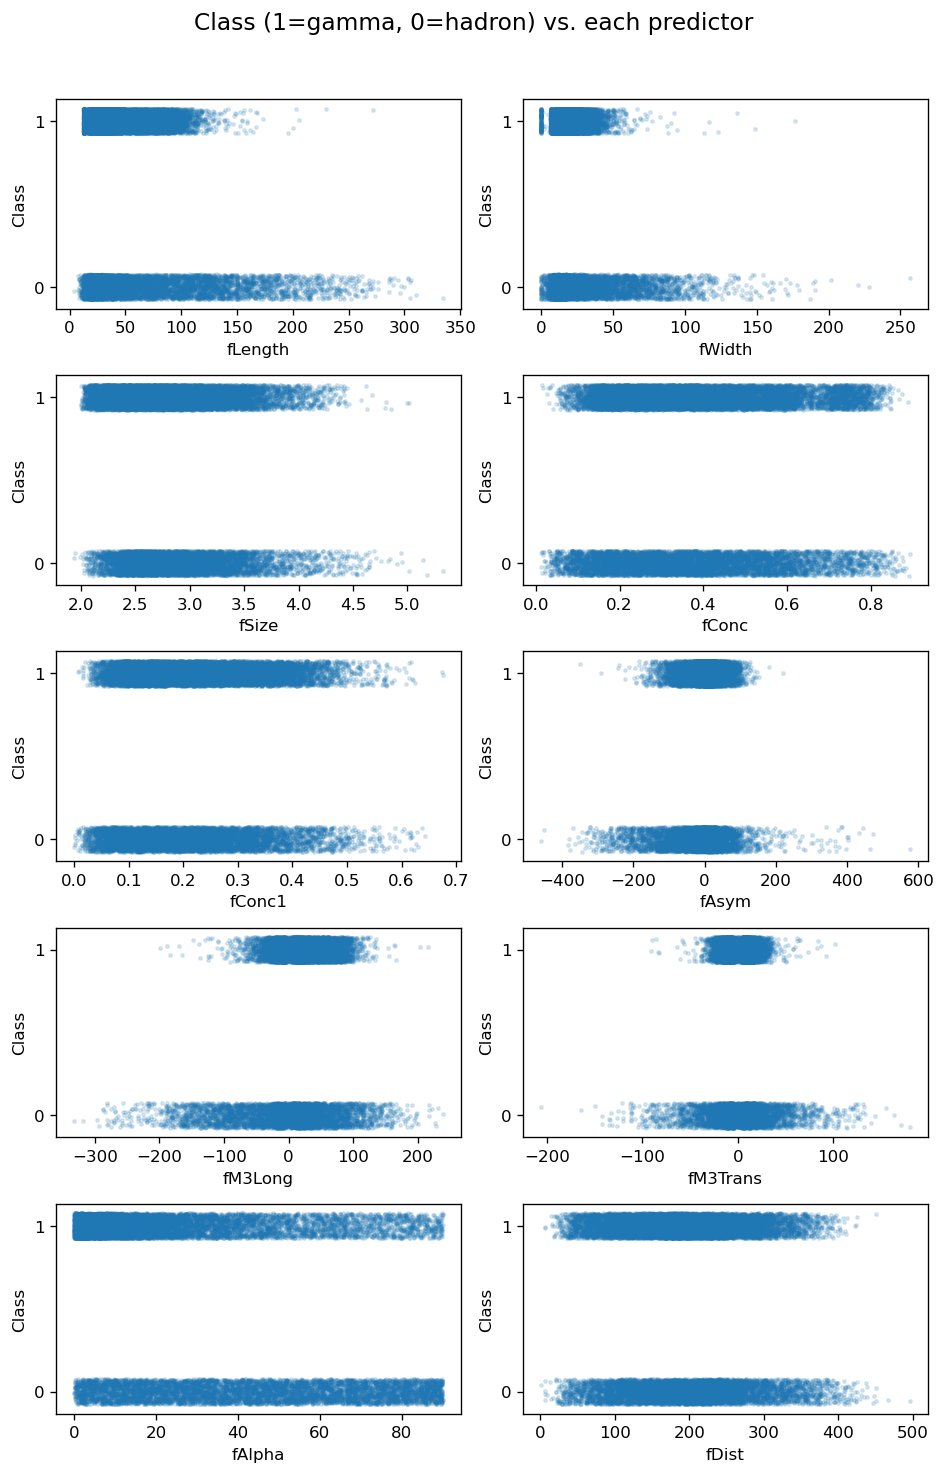

In [15]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 12))

for ax, feat in zip(axes.flat, FEATURES):
    
    jitter = (np.random.rand(len(y)) - 0.5) * 0.15
    ax.scatter(df[feat], y + jitter, s=4, alpha=0.15)
    ax.set_xlabel(feat)
    ax.set_ylabel("Class")
    ax.set_yticks([0, 1])


fig.suptitle("Class (1=gamma, 0=hadron) vs. each predictor", fontsize=14, y=1.02)
fig.tight_layout()


plt.savefig("stacked_features.pdf", format="pdf", bbox_inches="tight")

plt.show()

## 8. Confusion matrices and performance metrics

We get class predictions for every observation from the fold where it was held out, then
build the confusion matrix and the standard metrics: sensitivity (recall), specificity,
precision, and F1.

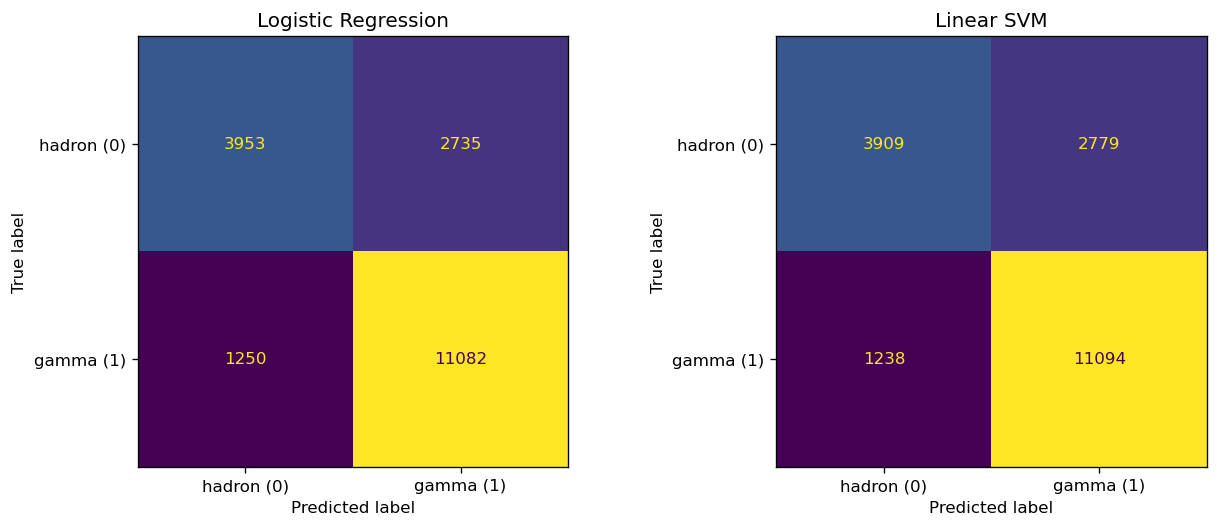

,Sensitivity,Specificity,Precision,F1
Logistic Regression,0.8986,0.5911,0.8021,0.8476
Linear SVM,0.8996,0.5845,0.7997,0.8467


In [9]:
def metrics_from_preds(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Precision":   precision_score(y_true, y_pred),
        "F1":          f1_score(y_true, y_pred),
    }

lr_pred  = cross_val_predict(make_lr(best_lr_lambda),  X, y, cv=cv)
svm_pred = cross_val_predict(make_svm(best_svm_lambda), X, y, cv=cv)

fig, ax, = plt.subplots(1, 2, figsize=(11, 4.5))
for a, preds, name in zip(ax, [lr_pred, svm_pred],
                          ["Logistic Regression", "Linear SVM"]):
    ConfusionMatrixDisplay(confusion_matrix(y, preds),
                           display_labels=["hadron (0)", "gamma (1)"]).plot(ax=a, colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

perf = pd.DataFrame({
    "Logistic Regression": metrics_from_preds(y, lr_pred),
    "Linear SVM":          metrics_from_preds(y, svm_pred),
}).T.round(4)
perf

### Final model estimation on the full dataset

For the chosen logistic-regression model we refit on **all 19,020 observations** and report
the coefficients. Because features were standardized, each coefficient is directly
comparable: larger magnitude = stronger influence on the gamma-vs-hadron decision. (The
sign tells direction: positive pushes toward gamma.)

In [10]:
final_lr = make_lr(best_lr_lambda).fit(X, y)
coef = final_lr.named_steps["logisticregression"].coef_[0]
intercept = final_lr.named_steps["logisticregression"].intercept_[0]

coef_table = (pd.DataFrame({"feature": FEATURES, "coefficient": coef})
              .assign(abs_coef=lambda d: d.coefficient.abs())
              .sort_values("abs_coef", ascending=False)
              .drop(columns="abs_coef")
              .reset_index(drop=True))
print(f"Intercept: {intercept:.4f}")
coef_table

Intercept: 0.6450


,feature,coefficient
0,fLength,-1.254125
1,fAlpha,-1.178653
2,fConc1,-0.600227
3,fM3Long,0.365443
4,fSize,-0.304384
5,fWidth,-0.100630
6,fDist,-0.041967
7,fM3Trans,0.013238
8,fConc,0.007070
9,fAsym,-0.001463


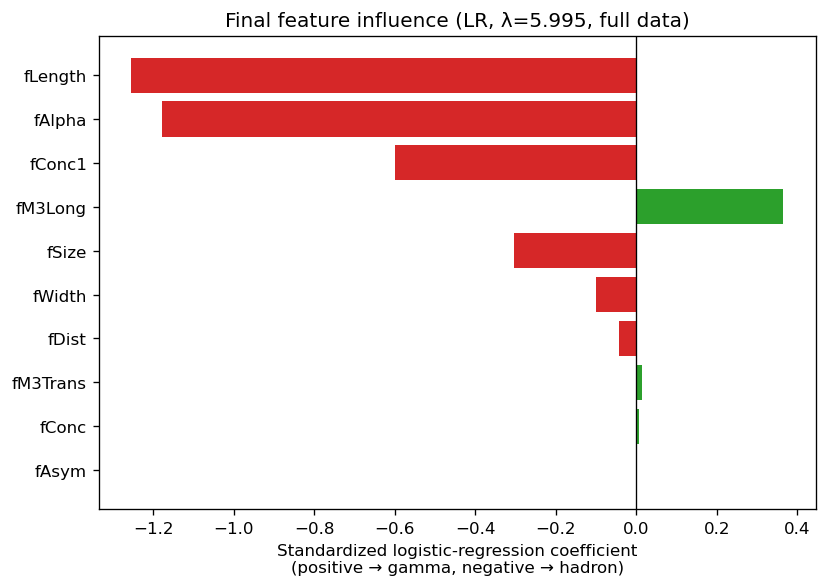

In [11]:

ct = coef_table.iloc[::-1]
plt.figure(figsize=(7, 5))
colors = ["tab:green" if c > 0 else "tab:red" for c in ct.coefficient]
plt.barh(ct.feature, ct.coefficient, color=colors)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("Standardized logistic-regression coefficient\n(positive → gamma, negative → hadron)")
plt.title(f"Final feature influence (LR, λ={best_lr_lambda:.3f}, full data)")
plt.tight_layout(); plt.show()